# IoT network intrusion classification
## PRT565 Assessment 3 — Machine Learning, Artificial Intelligence and Algorithms

**Group number:** [TO COMPLETE]  
**Members and student IDs:** [TO COMPLETE]  
**Campus:** [TO COMPLETE]

**Research question:** How do Decision Tree, Random Forest, Gaussian Naive Bayes and a multilayer ANN compare when classifying the 12 RT-IoT2022 traffic classes?

**Motivation:** Network monitoring produces many flow records. Comparing interpretable trees, probabilistic learning and a neural network helps assess the trade-off between overall accuracy and detection of less frequent traffic classes. This is an offline completed-flow benchmark, not evidence of operational detection performance.

The UCI source meets the assignment's dataset rule. This notebook implements the four named model families; RNN/LSTM are optional, and the supplied file does not provide trustworthy ordered sessions for a sequence model.

Run all cells in order. Data downloads from UCI if missing. Results are written to `outputs/`. The report and PowerPoint are separate deliverables.

### Connection to the supplied modules
| Module | Application here |
|---|---|
| Week 3, slides 3–7 | Data quality, median imputation, standard scaling, one-hot encoding |
| Week 4, slides 3–30 | Tree splits, overfitting, random forests and bootstrapping |
| Week 5, slides 8–18 | Naive Bayes assumptions, accuracy, precision, recall, F1, confusion matrices |
| Week 6 tutorial | Univariate/bivariate/multivariate analysis, numeric transformation, engineered features |
| Week 7, slides 3–12 | Feature selection, transparent reporting, robustness and privacy |
| Week 8, slides 10–15; Week 9 MLP tutorial | Two hidden layers, ReLU, softmax, backpropagation, dropout and learning curves |

The Week 9 tutorial uses MNIST, 512-unit layers and RMSprop. Here the tabular task uses smaller validation-compared layers and Adam; the multilayer architecture, sparse categorical loss and dropout principles are retained. Choices are explained rather than copied mechanically.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
import json, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "sklearn": sklearn.__version__,
            "tensorflow": tf.__version__}
print(versions)
from sklearn.model_selection import StratifiedGroupKFold
import hashlib, urllib.request, zipfile, io
OUTPUT = Path("outputs")
OUTPUT.mkdir(exist_ok=True)

{'python': '3.12.10', 'numpy': '2.5.3', 'pandas': '3.0.6', 'sklearn': '1.9.1', 'tensorflow': '2.21.0'}


## 1. Dataset and audit
Source: https://archive.ics.uci.edu/dataset/942/rt-iot2022

S., B., & Nagapadma, R. (2023). RT-IoT2022 [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5P338. License: CC BY 4.0.

The downloaded file has 123,117 records, 83 predictors, one exported row index and a target. Counts and normal-class names in UCI's descriptive text differ from the downloadable file; this experiment reports the file's actual labels. Exclude the exported index, remove exact duplicate records and audit conflicting labels. No class is removed to improve accuracy.

In [2]:
DATA_PATH = Path("data/dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(exist_ok=True)
    payload = urllib.request.urlopen("https://archive.ics.uci.edu/static/public/942/rt-iot2022.zip", timeout=120).read()
    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        DATA_PATH.write_bytes(archive.read("RT_IOT2022"))
dataset_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
raw = pd.read_csv(DATA_PATH)
TARGET = "Attack_type"
df = raw.drop(columns=[c for c in raw if c.startswith("Unnamed:")]).copy()
assert df[TARGET].notna().all()
duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
base_features = [c for c in df if c != TARGET]
numeric = df[base_features].select_dtypes(include=np.number).columns.tolist()
categorical = [c for c in base_features if c not in numeric]
df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
groups = pd.util.hash_pandas_object(df[base_features], index=False)
conflicts = df.groupby(groups)[TARGET].nunique().gt(1).sum()
print("Raw shape:", raw.shape, "Predictors:", len(base_features))
print("Exact duplicate records removed:", duplicate_count, "Remaining:", len(df))
print("Feature groups with conflicting labels:", conflicts)
print("SHA256:", dataset_sha256)
display(df[TARGET].value_counts().rename("records").to_frame())
audit = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(), "unique": df.nunique()})
display(audit)
audit.to_csv(OUTPUT / "data_audit.csv")

Raw shape: (123117, 85) Predictors: 83
Exact duplicate records removed: 5195 Remaining: 117922
Feature groups with conflicting labels: 6
SHA256: 956956c09c1764584fa08acd0f6876475626bcedcd6a6b1f8c492c2e9a2089ea


,records
Attack_type,
DOS_SYN_Hping,90089
Thing_Speak,7654
ARP_poisioning,7625
MQTT_Publish,4142
NMAP_UDP_SCAN,2584
NMAP_XMAS_TREE_SCAN,2010
NMAP_OS_DETECTION,2000
NMAP_TCP_scan,1002
DDOS_Slowloris,533


,dtype,missing,unique
id.orig_p,int64,0,65478
id.resp_p,int64,0,1809
proto,str,0,3
service,str,0,10
flow_duration,float64,0,16383
...,...,...,...
idle.std,float64,0,1001
fwd_init_window_size,int64,0,20
bwd_init_window_size,int64,0,56
fwd_last_window_size,int64,0,109


## 2. Fixed partitions
Use the first fold of seeded, five-fold stratified group splitting for the test set, then repeat within development data for validation: approximately 64% fitting, 16% validation and 20% test. Identical predictor vectors remain together, including conflicting-label records. Assert that every class is represented and no feature group crosses partitions.

These partitions assess performance within this capture environment. Session/device identifiers and timestamps suitable for an independent deployment split are not provided here; correlated flows may still cross partitions. Results do not establish performance on new networks or unseen attacks.

In [3]:
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
dev_idx, test_idx = next(splitter.split(df[base_features], df[TARGET], groups))
train_df, test_df = df.iloc[dev_idx].copy(), df.iloc[test_idx].copy()
fit_idx, val_idx = next(splitter.split(train_df[base_features], train_df[TARGET], groups.loc[train_df.index]))
fit_df, val_df = train_df.iloc[fit_idx].copy(), train_df.iloc[val_idx].copy()
parts = {"fit": fit_df, "validation": val_df, "test": test_df}
for name, part in parts.items():
    assert set(part[TARGET]) == set(df[TARGET]), f"Missing class in {name}"
    print(name, part.shape)
for a, b in [(fit_df, val_df), (fit_df, test_df), (val_df, test_df)]:
    assert set(groups.loc[a.index]).isdisjoint(groups.loc[b.index])
split_counts = pd.DataFrame({name: part[TARGET].value_counts() for name, part in parts.items()})
display(split_counts)
split_counts.to_csv(OUTPUT / "split_class_counts.csv")
pd.concat([pd.DataFrame({"source_row": part.index, "split": name}) for name, part in parts.items()]).to_csv(OUTPUT / "split_membership.csv", index=False)

fit (75469, 84)
validation (18868, 84)
test (23585, 84)


,fit,validation,test
Attack_type,,,
DOS_SYN_Hping,57657,14415,18017
Thing_Speak,4898,1225,1531
ARP_poisioning,4880,1220,1525
MQTT_Publish,2651,663,828
NMAP_UDP_SCAN,1654,413,517
NMAP_XMAS_TREE_SCAN,1287,321,402
NMAP_OS_DETECTION,1280,320,400
NMAP_TCP_scan,641,160,201
DDOS_Slowloris,341,86,106


## 3. Fitting-data exploration
Inspect class imbalance and traffic distributions before model selection.

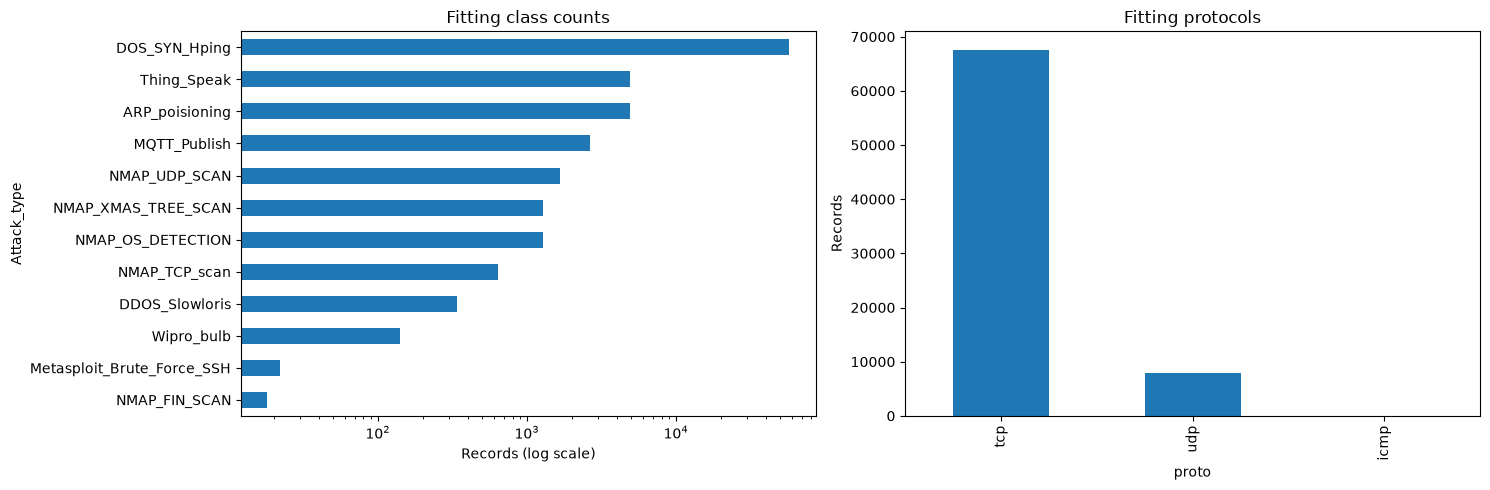

,flow_duration,fwd_pkts_tot,bwd_pkts_tot
count,75469.000000,75469.000000,75469.000000
mean,4.033563,2.271582,1.816984
std,147.092472,22.943807,11.249676
min,0.000000,0.000000,0.000000
25%,0.000001,1.000000,1.000000
50%,0.000004,1.000000,1.000000
75%,0.000005,1.000000,1.000000
max,21728.335578,4345.000000,1755.000000


Missing fitting values: 0


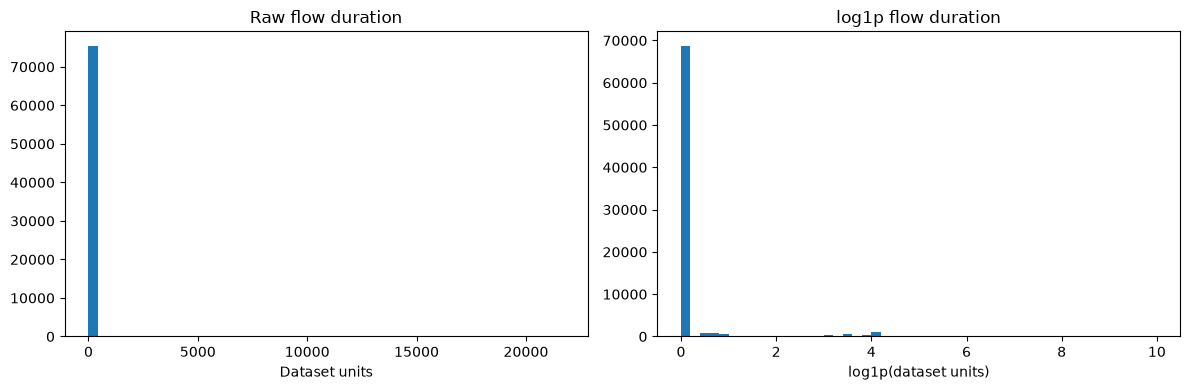

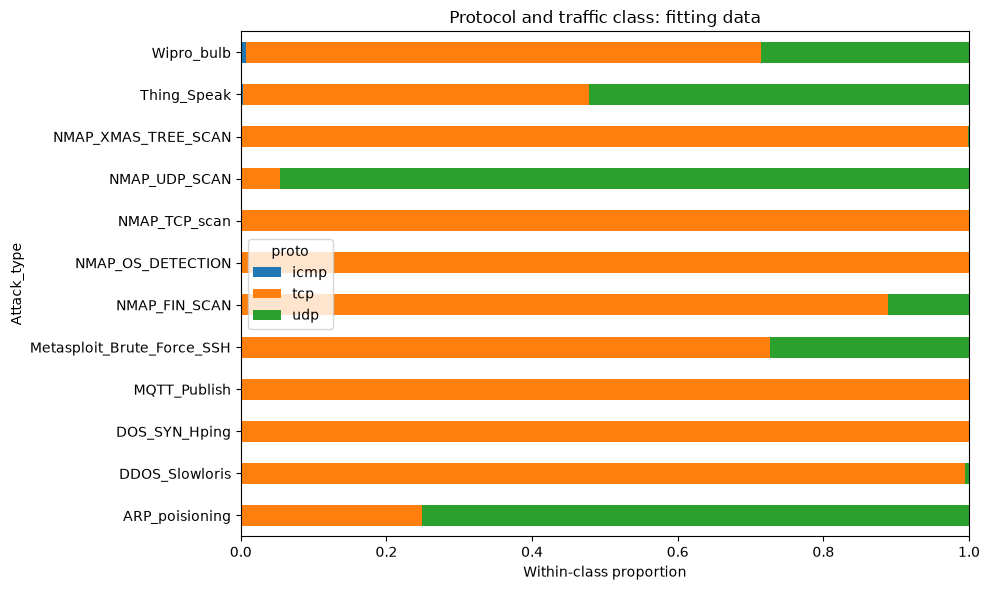

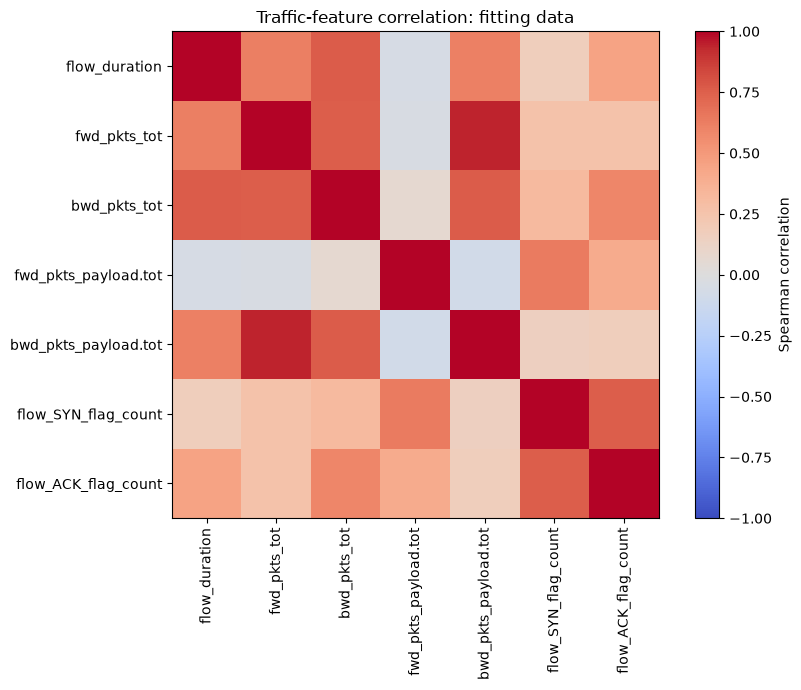

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fit_df[TARGET].value_counts().sort_values().plot.barh(ax=axes[0])
axes[0].set(title="Fitting class counts", xlabel="Records (log scale)", xscale="log")
fit_df["proto"].value_counts().plot.bar(ax=axes[1])
axes[1].set(title="Fitting protocols", ylabel="Records")
fig.tight_layout(); fig.savefig(OUTPUT / "class_distribution.png", dpi=150); plt.show()
display(fit_df[["flow_duration", "fwd_pkts_tot", "bwd_pkts_tot"]].describe())
print("Missing fitting values:", int(fit_df[base_features].isna().sum().sum()))
# Week 6: skewness, bivariate class differences and multivariate correlation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
values = fit_df["flow_duration"].clip(lower=0)
axes[0].hist(values, bins=50); axes[0].set(title="Raw flow duration", xlabel="Dataset units")
axes[1].hist(np.log1p(values), bins=50); axes[1].set(title="log1p flow duration", xlabel="log1p(dataset units)")
fig.tight_layout(); fig.savefig(OUTPUT / "duration_transformation.png", dpi=160); plt.show()
crosstab = pd.crosstab(fit_df[TARGET], fit_df["proto"], normalize="index")
crosstab.plot.barh(stacked=True, figsize=(10, 6))
plt.xlabel("Within-class proportion"); plt.title("Protocol and traffic class: fitting data")
plt.tight_layout(); plt.savefig(OUTPUT / "protocol_by_class.png", dpi=160); plt.show()
corr_columns = ["flow_duration", "fwd_pkts_tot", "bwd_pkts_tot", "fwd_pkts_payload.tot", "bwd_pkts_payload.tot", "flow_SYN_flag_count", "flow_ACK_flag_count"]
correlations = fit_df[corr_columns].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlations, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_columns)), corr_columns, rotation=90)
ax.set_yticks(range(len(corr_columns)), corr_columns)
fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Traffic-feature correlation: fitting data")
fig.tight_layout(); fig.savefig(OUTPUT / "feature_correlations.png", dpi=160); plt.show()
correlations.to_csv(OUTPUT / "feature_correlations.csv")


## 4. Features and preprocessing
Use all 83 traffic predictors; exclude the row index and target. Compare raw numeric values against signed log1p transformation to reduce skew in flow magnitudes. This transformation has no fitted parameters. Fit median imputation, standard scaling and categorical one-hot encoding only on the fitting partition during selection. Ports are capture-specific predictors; high performance may partly reflect the laboratory setup. Some predictors require a completed flow.

In [5]:
def make_features(frame, feature_set):
    result = frame[base_features].copy()
    if feature_set == "log_numeric":
        result[numeric] = np.sign(result[numeric]) * np.log1p(np.abs(result[numeric]))
    return result

def make_preprocessor(X):
    categories = [c for c in X.columns if c not in numeric]
    return ColumnTransformer([
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")),
                              ("scaler", StandardScaler())]), numeric),
        ("category", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                               ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categories)
    ])

encoder = LabelEncoder().fit(fit_df[TARGET])
classes = encoder.classes_
y_fit = encoder.transform(fit_df[TARGET])
y_val = encoder.transform(val_df[TARGET])
y_train = encoder.transform(train_df[TARGET])
def scores(y, predictions):
    return {"accuracy": accuracy_score(y, predictions),
            "precision_macro": precision_score(y, predictions, average="macro", zero_division=0),
            "recall_macro": recall_score(y, predictions, average="macro", zero_division=0),
            "f1_macro": f1_score(y, predictions, average="macro", zero_division=0)}
print("Classes:", dict(enumerate(classes)))

Classes: {0: 'ARP_poisioning', 1: 'DDOS_Slowloris', 2: 'DOS_SYN_Hping', 3: 'MQTT_Publish', 4: 'Metasploit_Brute_Force_SSH', 5: 'NMAP_FIN_SCAN', 6: 'NMAP_OS_DETECTION', 7: 'NMAP_TCP_scan', 8: 'NMAP_UDP_SCAN', 9: 'NMAP_XMAS_TREE_SCAN', 10: 'Thing_Speak', 11: 'Wipro_bulb'}


## 5. Decision Tree, Random Forest and Naive Bayes
Select settings using validation macro F1, which weights classes equally. Compare against a majority-class baseline. Gaussian Naive Bayes assumptions may not suit one-hot inputs.

Week 4 discusses entropy/information gain. This implementation uses scikit-learn's default Gini impurity for tree splits: a different impurity measure with the same recursive-partition principle. Depth and minimum leaf size are compared to control overfitting; Random Forest uses bootstrap samples and random feature subsets. Gaussian Naive Bayes is appropriate as a simple numeric baseline, although its Gaussian and conditional-independence assumptions are imperfect for these flow features.

In [6]:
specs = {
    "Decision Tree": (DecisionTreeClassifier(random_state=SEED),
                      {"max_depth": [10, None], "min_samples_leaf": [1, 5]}),
    "Random Forest": (RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
                      {"max_depth": [16, None], "min_samples_leaf": [1, 5]}),
    "Naive Bayes": (GaussianNB(), {"var_smoothing": [1e-9, 1e-5, 1e-2]})
}
search_rows, chosen = [], {}
for name, (estimator, grid) in specs.items():
    best = None
    for feature_set in ["base", "log_numeric"]:
        Xf, Xv = make_features(fit_df, feature_set), make_features(val_df, feature_set)
        for params in ParameterGrid(grid):
            model = Pipeline([("preprocessing", make_preprocessor(Xf)),
                              ("classifier", clone(estimator).set_params(**params))])
            model.fit(Xf, y_fit)
            metrics = scores(y_val, model.predict(Xv))
            row = {"model": name, "features": feature_set, "parameters": json.dumps(params), **metrics}
            search_rows.append(row)
            if best is None or metrics["f1_macro"] > best["f1_macro"]:
                best = {**row, "pipeline": model}
    chosen[name] = best
    print(name, "validation macro F1:", round(best["f1_macro"], 4), best["features"])
dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y_fit), 1)), y_fit)
dummy_val = scores(y_val, dummy.predict(np.zeros((len(y_val), 1))))
search_table = pd.DataFrame(search_rows)
display(search_table.sort_values("f1_macro", ascending=False))
print("Baseline validation:", dummy_val)

Decision Tree validation macro F1: 0.9771 base


Random Forest validation macro F1: 0.9739 log_numeric


Naive Bayes validation macro F1: 0.676 log_numeric


,model,features,parameters,accuracy,precision_macro,recall_macro,f1_macro
2,Decision Tree,base,"{""max_depth"": null, ""min_samples_leaf"": 1}",0.998145,0.990017,0.967198,0.977105
0,Decision Tree,base,"{""max_depth"": 10, ""min_samples_leaf"": 1}",0.997615,0.994205,0.961755,0.976193
12,Random Forest,log_numeric,"{""max_depth"": 16, ""min_samples_leaf"": 1}",0.998569,0.998032,0.954375,0.973912
10,Random Forest,base,"{""max_depth"": null, ""min_samples_leaf"": 1}",0.998463,0.997899,0.951474,0.972264
4,Decision Tree,log_numeric,"{""max_depth"": 10, ""min_samples_leaf"": 1}",0.997403,0.991139,0.956857,0.972062
14,Random Forest,log_numeric,"{""max_depth"": null, ""min_samples_leaf"": 1}",0.998463,0.997900,0.949614,0.971166
8,Random Forest,base,"{""max_depth"": 16, ""min_samples_leaf"": 1}",0.998410,0.996919,0.949093,0.970423
6,Decision Tree,log_numeric,"{""max_depth"": null, ""min_samples_leaf"": 1}",0.997774,0.968453,0.966720,0.967572
11,Random Forest,base,"{""max_depth"": null, ""min_samples_leaf"": 5}",0.997880,0.975802,0.940886,0.956468
13,Random Forest,log_numeric,"{""max_depth"": 16, ""min_samples_leaf"": 5}",0.997827,0.975736,0.940818,0.956401


Baseline validation: {'accuracy': 0.7639919440322239, 'precision_macro': 0.06366599533601866, 'recall_macro': 0.08333333333333333, 'f1_macro': 0.07218399783673347}


## 6. Multilayer ANN
Two ReLU hidden layers with dropout and a softmax output for the observed classes. Compare (32,16) and (64,32) architectures and raw versus log numeric features. Use Adam, sparse categorical cross-entropy and validation-loss early stopping. Select the configuration using validation macro F1; select refit epochs using the minimum validation loss. All models use the same partitions.

MLP base (32, 16) validation macro F1: 0.7626


MLP base (64, 32) validation macro F1: 0.9499


MLP log_numeric (32, 16) validation macro F1: 0.7939


MLP log_numeric (64, 32) validation macro F1: 0.9611


,model,features,widths,best_epoch,accuracy,precision_macro,recall_macro,f1_macro
0,MLP,base,"[32, 16]",28,0.992686,0.819712,0.744832,0.762620
1,MLP,base,"[64, 32]",26,0.995336,0.990842,0.918957,0.949867
2,MLP,log_numeric,"[32, 16]",36,0.995018,0.820801,0.776482,0.793940
3,MLP,log_numeric,"[64, 32]",30,0.995866,0.991213,0.938077,0.961065


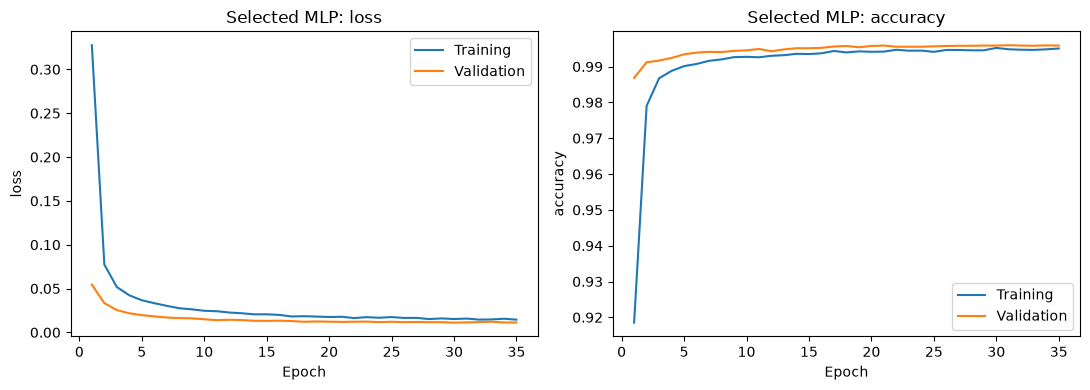

In [7]:
def build_ann(widths, input_width):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_width,)),
        tf.keras.layers.Dense(widths[0], activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(widths[1], activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(len(classes), activation="softmax")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

ann_best, ann_rows = None, []
for feature_set in ["base", "log_numeric"]:
    Xf, Xv = make_features(fit_df, feature_set), make_features(val_df, feature_set)
    prep = make_preprocessor(Xf)
    Zf = prep.fit_transform(Xf).astype("float32")
    Zv = prep.transform(Xv).astype("float32")
    for widths in [(32, 16), (64, 32)]:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        ann = build_ann(widths, Zf.shape[1])
        history = ann.fit(Zf, y_fit, validation_data=(Zv, y_val), epochs=40,
                          batch_size=256, verbose=0,
                          callbacks=[tf.keras.callbacks.EarlyStopping(
                              monitor="val_loss", patience=5, restore_best_weights=True)])
        predictions = ann.predict(Zv, verbose=0).argmax(axis=1)
        metrics = scores(y_val, predictions)
        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        row = {"model": "MLP", "features": feature_set, "widths": list(widths),
               "best_epoch": best_epoch, **metrics}
        ann_rows.append(row)
        if ann_best is None or metrics["f1_macro"] > ann_best["f1_macro"]:
            ann_best = {**row, "history": history.history}
        print("MLP", feature_set, widths, "validation macro F1:", round(metrics["f1_macro"], 4))
display(pd.DataFrame(ann_rows))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["loss", "accuracy"]):
    h = ann_best["history"]
    ax.plot(range(1, len(h[metric]) + 1), h[metric], label="Training")
    ax.plot(range(1, len(h[metric]) + 1), h["val_" + metric], label="Validation")
    ax.set(xlabel="Epoch", ylabel=metric, title="Selected MLP: " + metric)
    ax.legend()
fig.tight_layout(); fig.savefig(OUTPUT / "ann_learning_curves.png", dpi=160); plt.show()

## 7. Validation feature comparison
Compare best validation macro F1 for raw and log numeric features. No test scores enter selection.

In [8]:
ablation = pd.concat([search_table, pd.DataFrame(ann_rows)], ignore_index=True)
ablation = ablation.groupby(["model", "features"])["f1_macro"].max().unstack()
display(ablation)
ablation.to_csv(OUTPUT / "feature_comparison.csv")

features,base,log_numeric
model,,
Decision Tree,0.977105,0.972062
MLP,0.949867,0.961065
Naive Bayes,0.596936,0.675955
Random Forest,0.972264,0.973912


## Supplementary feature engineering and selection — Weeks 6 and 7
These course-aligned comparisons use only fitting and validation records. They are reported separately and do not alter the already evaluated primary models.

**Engineering:** combine forward and backward packet counts into a directional balance, (forward − backward)/(forward + backward + 1), and payload totals into a backward-payload share, backward/(forward + backward + 1). Add these two numeric features to the existing selected Random Forest feature representation.

**Selection:** rank encoded predictors using a 100-tree Random Forest fitted only to fitting records. Retain the top 20 encoded predictors and refit an otherwise identical Random Forest. Twenty is a fixed demonstration size, not a test-tuned optimum. Impurity importance can favor high-cardinality features and spread importance across correlated variables; it is an association, not a causal explanation.

Compare each with the selected full-feature Random Forest on the same validation set. No guarantee of improvement is assumed.

,feature,importance,selected
30,numeric__fwd_pkts_payload.avg,0.070577,True
1,numeric__id.resp_p,0.064373,True
27,numeric__fwd_pkts_payload.min,0.064131,True
28,numeric__fwd_pkts_payload.max,0.043897,True
29,numeric__fwd_pkts_payload.tot,0.043897,True
60,numeric__fwd_subflow_bytes,0.036525,True
54,numeric__flow_iat.tot,0.030213,True
38,numeric__flow_pkts_payload.max,0.029466,True
53,numeric__flow_iat.max,0.029136,True
55,numeric__flow_iat.avg,0.028599,True


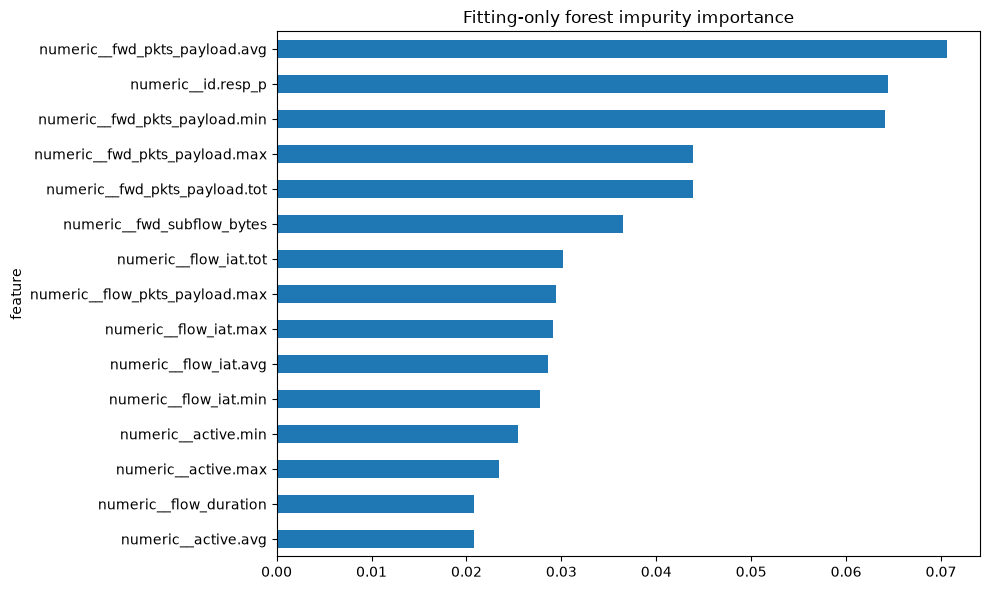

,experiment,encoded_features,accuracy,precision_macro,recall_macro,f1_macro
0,Full-feature selected RF,94,0.998569,0.998032,0.954375,0.973912
1,Top-20 encoded features,20,0.973712,0.812089,0.807826,0.806564
2,Two engineered ratios,96,0.998622,0.998102,0.955851,0.974771


Supplementary validation only; primary test model choices remain fixed.


In [9]:
from sklearn.feature_selection import SelectFromModel
rf_item = chosen["Random Forest"]
rf_params = json.loads(rf_item["parameters"])
rf_factory = lambda: RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED, **rf_params)
Xfit_rf = make_features(fit_df, rf_item["features"])
Xval_rf = make_features(val_df, rf_item["features"])
prep_rf = make_preprocessor(Xfit_rf)
Zfit_rf = prep_rf.fit_transform(Xfit_rf)
Zval_rf = prep_rf.transform(Xval_rf)
selector = SelectFromModel(rf_factory(), threshold=-np.inf, max_features=20)
Zfit_selected = selector.fit_transform(Zfit_rf, y_fit)
Zval_selected = selector.transform(Zval_rf)
selected_rf = rf_factory().fit(Zfit_selected, y_fit)
encoded_names = prep_rf.get_feature_names_out()
importance_table = pd.DataFrame({"feature": encoded_names, "importance": selector.estimator_.feature_importances_, "selected": selector.get_support()}).sort_values("importance", ascending=False)
importance_table.to_csv(OUTPUT / "feature_importance.csv", index=False)
display(importance_table.head(20))
importance_table.head(15).sort_values("importance").plot.barh(x="feature", y="importance", legend=False, figsize=(10, 6))
plt.title("Fitting-only forest impurity importance"); plt.tight_layout()
plt.savefig(OUTPUT / "feature_importance.png", dpi=160); plt.show()

def engineered_features(frame):
    X = make_features(frame, rf_item["features"])
    fwd, bwd = frame["fwd_pkts_tot"], frame["bwd_pkts_tot"]
    X["packet_direction_balance"] = (fwd - bwd) / (fwd + bwd + 1)
    fbytes, bbytes = frame["fwd_pkts_payload.tot"], frame["bwd_pkts_payload.tot"]
    X["backward_payload_share"] = bbytes / (fbytes + bbytes + 1)
    return X
Xfit_eng, Xval_eng = engineered_features(fit_df), engineered_features(val_df)
eng_numeric = numeric + ["packet_direction_balance", "backward_payload_share"]
eng_prep = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), eng_numeric),
    ("categorical", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical)
])
engineered_rf = Pipeline([("preprocessing", eng_prep), ("classifier", rf_factory())]).fit(Xfit_eng, y_fit)
feature_experiments = pd.DataFrame([
    {"experiment": "Full-feature selected RF", "encoded_features": Zfit_rf.shape[1], **scores(y_val, rf_item["pipeline"].predict(Xval_rf))},
    {"experiment": "Top-20 encoded features", "encoded_features": Zfit_selected.shape[1], **scores(y_val, selected_rf.predict(Zval_selected))},
    {"experiment": "Two engineered ratios", "encoded_features": len(engineered_rf.named_steps["preprocessing"].get_feature_names_out()), **scores(y_val, engineered_rf.predict(Xval_eng))}
])
display(feature_experiments)
feature_experiments.to_csv(OUTPUT / "supplementary_validation.csv", index=False)
print("Supplementary validation only; primary test model choices remain fixed.")


## 8. Final evaluation
Refit selected models on 80% of the data. Train the ANN for the epoch count selected during validation. Evaluate every model on the same 20% test set.

Select the recommended model using validation macro F1. Do not retune using test results.

Week 5 metrics are computed class by class, then averaged without class weights for macro precision, recall and F1. For each class: precision = TP/(TP+FP), recall = TP/(TP+FN), F1 = 2PR/(P+R). Accuracy = all correct predictions / all records. Macro F1 is the mean of class F1 values, not the F1 of macro precision and recall. Undefined metrics use zero. A false negative for an attack class means the model assigned that record another class; that may be a different attack, not necessarily benign traffic.

In [10]:
selection = {name: {k: v for k, v in item.items() if k != "pipeline"}
             for name, item in chosen.items()}
selection["MLP"] = {k: v for k, v in ann_best.items() if k != "history"}
validation_scores = {name: item["f1_macro"] for name, item in selection.items()}
validation_scores["Majority baseline"] = dummy_val["f1_macro"]
recommended = max(validation_scores, key=validation_scores.get)
y_test = encoder.transform(test_df[TARGET])
final_predictions, test_rows, fitted_models = {}, [], {}
for name, item in chosen.items():
    start = time.perf_counter()
    model = clone(item["pipeline"])
    model.fit(make_features(train_df, item["features"]), y_train)
    elapsed = time.perf_counter() - start
    predictions = model.predict(make_features(test_df, item["features"]))
    final_predictions[name] = predictions
    fitted_models[name] = model
    test_rows.append({"model": name, **scores(y_test, predictions), "fit_seconds": elapsed})

start = time.perf_counter()
ann_prep = make_preprocessor(make_features(train_df, ann_best["features"]))
Ztrain = ann_prep.fit_transform(make_features(train_df, ann_best["features"])).astype("float32")
Ztest = ann_prep.transform(make_features(test_df, ann_best["features"])).astype("float32")
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
final_ann = build_ann(ann_best["widths"], Ztrain.shape[1])
final_ann.fit(Ztrain, y_train, epochs=ann_best["best_epoch"], batch_size=256, verbose=0)
elapsed = time.perf_counter() - start
final_predictions["MLP"] = final_ann.predict(Ztest, verbose=0).argmax(axis=1)
test_rows.append({"model": "MLP", **scores(y_test, final_predictions["MLP"]), "fit_seconds": elapsed})
baseline = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y_train), 1)), y_train)
final_predictions["Majority baseline"] = baseline.predict(np.zeros((len(y_test), 1)))
test_rows.append({"model": "Majority baseline", **scores(y_test, final_predictions["Majority baseline"]),
                  "fit_seconds": np.nan})
results = pd.DataFrame(test_rows).set_index("model")
display(results.round(4))
print("Model selected using validation macro F1:", recommended)

,accuracy,precision_macro,recall_macro,f1_macro,fit_seconds
model,,,,,
Decision Tree,0.9979,0.9727,0.9683,0.9705,1.4533
Random Forest,0.9984,0.9891,0.9708,0.9784,1.4773
Naive Bayes,0.9292,0.6455,0.8368,0.6519,0.9244
MLP,0.9959,0.9860,0.9385,0.9593,20.4948
Majority baseline,0.7639,0.0637,0.0833,0.0722,NaN


Model selected using validation macro F1: Decision Tree


Decision Tree


,precision,recall,f1-score,support,model
ARP_poisioning,0.9863,0.9889,0.9876,1525.0000,Decision Tree
DDOS_Slowloris,0.9905,0.9811,0.9858,106.0000,Decision Tree
DOS_SYN_Hping,1.0000,1.0000,1.0000,18017.0000,Decision Tree
MQTT_Publish,1.0000,0.9976,0.9988,828.0000,Decision Tree
Metasploit_Brute_Force_SSH,0.7500,0.7500,0.7500,8.0000,Decision Tree
NMAP_FIN_SCAN,1.0000,1.0000,1.0000,6.0000,Decision Tree
NMAP_OS_DETECTION,1.0000,1.0000,1.0000,400.0000,Decision Tree
NMAP_TCP_scan,0.9950,0.9900,0.9925,201.0000,Decision Tree
NMAP_UDP_SCAN,0.9885,0.9942,0.9913,517.0000,Decision Tree
NMAP_XMAS_TREE_SCAN,0.9975,0.9975,0.9975,402.0000,Decision Tree


Random Forest


,precision,recall,f1-score,support,model
ARP_poisioning,0.9876,0.9941,0.9908,1525.0000,Random Forest
DDOS_Slowloris,0.9811,0.9811,0.9811,106.0000,Random Forest
DOS_SYN_Hping,1.0000,1.0000,1.0000,18017.0000,Random Forest
MQTT_Publish,1.0000,0.9976,0.9988,828.0000,Random Forest
Metasploit_Brute_Force_SSH,1.0000,0.7500,0.8571,8.0000,Random Forest
NMAP_FIN_SCAN,1.0000,1.0000,1.0000,6.0000,Random Forest
NMAP_OS_DETECTION,1.0000,1.0000,1.0000,400.0000,Random Forest
NMAP_TCP_scan,1.0000,0.9900,0.9950,201.0000,Random Forest
NMAP_UDP_SCAN,0.9942,0.9942,0.9942,517.0000,Random Forest
NMAP_XMAS_TREE_SCAN,1.0000,0.9975,0.9988,402.0000,Random Forest


Naive Bayes


,precision,recall,f1-score,support,model
ARP_poisioning,0.8867,0.3489,0.5007,1525.0000,Naive Bayes
DDOS_Slowloris,0.1538,0.9811,0.2660,106.0000,Naive Bayes
DOS_SYN_Hping,1.0000,1.0000,1.0000,18017.0000,Naive Bayes
MQTT_Publish,1.0000,0.9891,0.9945,828.0000,Naive Bayes
Metasploit_Brute_Force_SSH,0.1935,0.7500,0.3077,8.0000,Naive Bayes
NMAP_FIN_SCAN,0.1622,1.0000,0.2791,6.0000,Naive Bayes
NMAP_OS_DETECTION,1.0000,1.0000,1.0000,400.0000,Naive Bayes
NMAP_TCP_scan,1.0000,0.9900,0.9950,201.0000,Naive Bayes
NMAP_UDP_SCAN,0.5157,0.9516,0.6689,517.0000,Naive Bayes
NMAP_XMAS_TREE_SCAN,1.0000,0.9975,0.9988,402.0000,Naive Bayes


MLP


,precision,recall,f1-score,support,model
ARP_poisioning,0.9709,0.9836,0.9772,1525.0000,MLP
DDOS_Slowloris,1.0000,0.8208,0.9016,106.0000,MLP
DOS_SYN_Hping,1.0000,1.0000,1.0000,18017.0000,MLP
MQTT_Publish,0.9988,0.9964,0.9976,828.0000,MLP
Metasploit_Brute_Force_SSH,1.0000,0.7500,0.8571,8.0000,MLP
NMAP_FIN_SCAN,1.0000,1.0000,1.0000,6.0000,MLP
NMAP_OS_DETECTION,1.0000,1.0000,1.0000,400.0000,MLP
NMAP_TCP_scan,1.0000,0.9900,0.9950,201.0000,MLP
NMAP_UDP_SCAN,0.9643,0.9923,0.9781,517.0000,MLP
NMAP_XMAS_TREE_SCAN,1.0000,0.9975,0.9988,402.0000,MLP


Majority baseline


,precision,recall,f1-score,support,model
ARP_poisioning,0.0000,0.0000,0.0000,1525.0000,Majority baseline
DDOS_Slowloris,0.0000,0.0000,0.0000,106.0000,Majority baseline
DOS_SYN_Hping,0.7639,1.0000,0.8662,18017.0000,Majority baseline
MQTT_Publish,0.0000,0.0000,0.0000,828.0000,Majority baseline
Metasploit_Brute_Force_SSH,0.0000,0.0000,0.0000,8.0000,Majority baseline
NMAP_FIN_SCAN,0.0000,0.0000,0.0000,6.0000,Majority baseline
NMAP_OS_DETECTION,0.0000,0.0000,0.0000,400.0000,Majority baseline
NMAP_TCP_scan,0.0000,0.0000,0.0000,201.0000,Majority baseline
NMAP_UDP_SCAN,0.0000,0.0000,0.0000,517.0000,Majority baseline
NMAP_XMAS_TREE_SCAN,0.0000,0.0000,0.0000,402.0000,Majority baseline


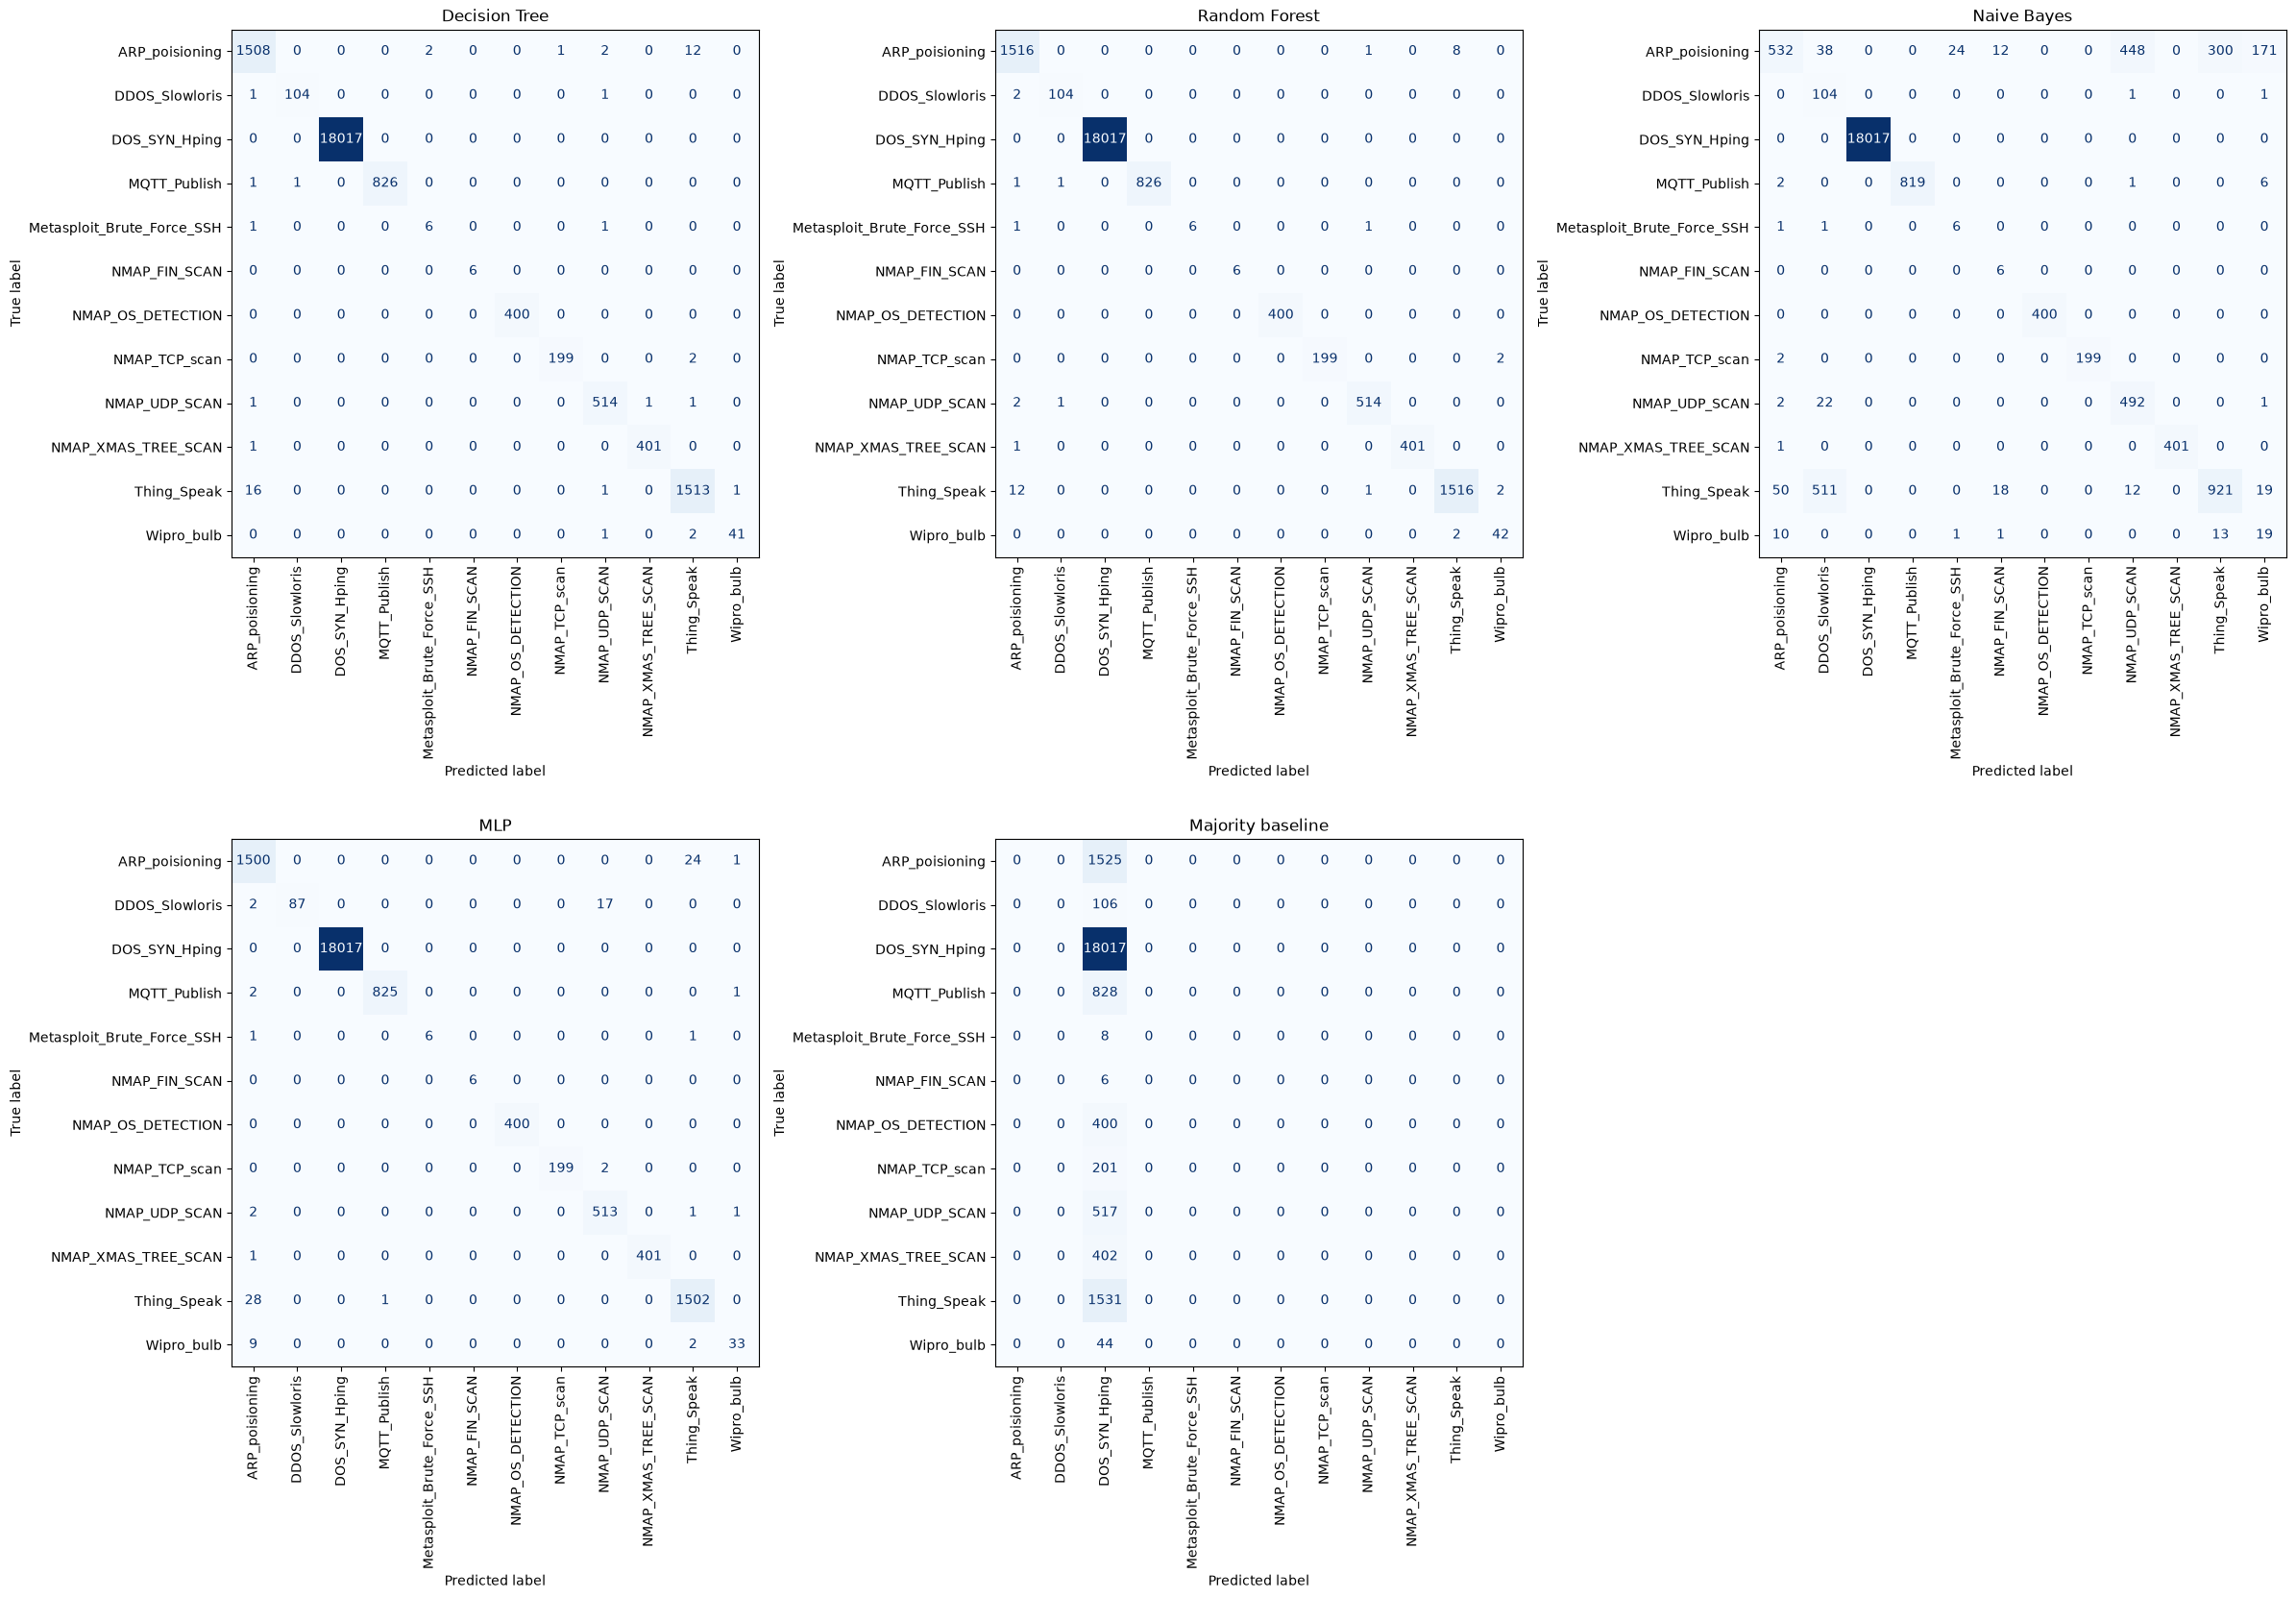

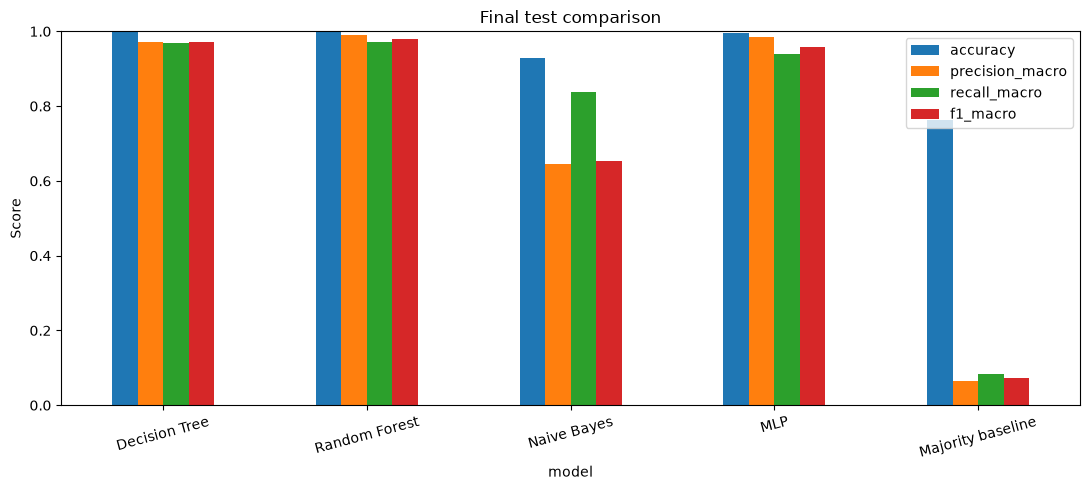

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(24, 17))
reports = []
for ax, (name, predictions) in zip(axes.flat, final_predictions.items()):
    assert len(predictions) == len(y_test)
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=classes,
        ax=ax, colorbar=False, cmap="Blues", xticks_rotation=90, values_format="d")
    ax.set_title(name)
    report = pd.DataFrame(classification_report(y_test, predictions, target_names=classes,
                        output_dict=True, zero_division=0)).T
    report["model"] = name
    reports.append(report)
    print(name); display(report.round(4))
axes.flat[-1].axis("off")
fig.tight_layout(); fig.savefig(OUTPUT / "confusion_matrices.png", dpi=140); plt.show()
ax = results[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot.bar(figsize=(11, 5))
plt.ylim(0, 1); plt.ylabel("Score"); plt.title("Final test comparison")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(OUTPUT / "test_comparison.png", dpi=150); plt.show()
results.to_csv(OUTPUT / "test_metrics.csv")
pd.concat(reports).to_csv(OUTPUT / "classification_reports.csv")

## 9. Findings and limitations
Interpret the measured results below. Accuracy weights frequent classes heavily; macro F1 gives each traffic class equal weight. Rare attack recall is uncertain because some classes have very few test records. Model selection uses validation macro F1, not the highest test accuracy.

Exact-duplicate removal and feature-group separation reduce one source of leakage but cannot establish independent sessions or devices. Laboratory traffic and capture-specific ports can make classification easier than deployment. Normal labels represent particular device traffic, not all benign networks. Gaussian Naive Bayes assumes conditionally independent Gaussian predictors; correlated, skewed traffic features can violate this assumption. The dataset provides no proof of generalization to future or unknown attacks. Do not change seeds or tune against these test results.

### Week 7: ethics and transparency
- Report poor rare-class performance, even when overall accuracy is high.
- Do not claim demographic fairness from this traffic dataset; no suitable demographic information is supplied.
- Minimize and protect identifiers if future operational traffic is collected; this benchmark does not need packet payload content or personal identities.
- Use models to support an analyst, with review of false alerts and missed attacks.
- Publish splits, preprocessing decisions, data hash, package versions and limitations so results can be checked.

### Experiment provenance
The primary model configurations and test partition were already evaluated before the course files were supplied. This revision adds course explanations and supplementary validation-only feature experiments. It does not change the primary grids, seed, split or selection rule in response to test results. Re-execution checks reproducibility; it is not a fresh independent test.

In [12]:
summary = (
    f"Validation-selected model: {recommended}\n"
    f"Selected model test accuracy: {results.loc[recommended, 'accuracy']:.4f}\n"
    f"Selected model test macro F1: {results.loc[recommended, 'f1_macro']:.4f}\n"
    f"Test majority baseline accuracy: {results.loc['Majority baseline', 'accuracy']:.4f}\n"
    "These are within-dataset benchmark results, not deployment performance.\n"
)
print(summary)
(OUTPUT / "summary.txt").write_text(summary, encoding="utf-8")
search_table.to_csv(OUTPUT / "classical_validation.csv", index=False)
pd.DataFrame(ann_rows).to_csv(OUTPUT / "ann_validation.csv", index=False)
pd.DataFrame(ann_best["history"]).to_csv(OUTPUT / "selected_ann_history.csv", index=False)
prediction_table = pd.DataFrame({"source_row": test_df.index, "actual": classes[y_test]})
for name, predictions in final_predictions.items():
    prediction_table[name] = classes[predictions]
prediction_table.to_csv(OUTPUT / "test_predictions.csv", index=False)
manifest = {"dataset": "UCI RT-IoT2022", "doi": "10.24432/C5P338", "sha256": dataset_sha256,
            "seed": SEED, "versions": versions, "selection": selection, "recommended": recommended,
            "raw_rows": len(raw), "deduplicated_rows": len(df), "predictors": base_features,
            "split": "first fold of seeded 5-fold StratifiedGroupKFold, repeated on development",
            "partition_sizes": {name: len(part) for name, part in parts.items()}}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
# Save fitted artifacts and the feature/label metadata needed to reproduce inference.
import joblib
model_dir = OUTPUT / "models"
model_dir.mkdir(exist_ok=True)
for name, fitted in fitted_models.items():
    joblib.dump(fitted, model_dir / (name.lower().replace(" ", "_") + ".joblib"))
joblib.dump(ann_prep, model_dir / "ann_preprocessor.joblib")
joblib.dump(encoder, model_dir / "label_encoder.joblib")
final_ann.save(model_dir / "ann.keras")
(model_dir / "feature_notes.txt").write_text("Apply make_features using the selected feature set from manifest.json before the saved pipeline or ANN preprocessor. Use label_encoder.joblib to decode classes. Only load trusted joblib files.", encoding="utf-8")


Validation-selected model: Decision Tree
Selected model test accuracy: 0.9979
Selected model test macro F1: 0.9705
Test majority baseline accuracy: 0.7639
These are within-dataset benchmark results, not deployment performance.



192

## References (APA style)
- S., B., & Nagapadma, R. (2023). *RT-IoT2022* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5P338
- *PRT565: Week 3—Data pre-processing, data scaling, logistic regression*. (n.d.). [Lecture slides]. Course materials supplied for PRT565.
- *PRT565: Week 4—Decision tree and random forests*. (n.d.). [Lecture slides]. Course materials supplied for PRT565.
- *PRT565: Week 5—K-nearest neighbour, Naive Bayes and supervised model evaluation*. (n.d.). [Lecture slides]. Course materials supplied for PRT565.
- *Week 6 PRT565: Data analysis, feature transformation and feature engineering*. (n.d.). [Jupyter notebook]. Course materials supplied for PRT565.
- *PRT565: Week 7—Feature selection algorithms and ethics in AI*. (n.d.). [Lecture slides]. Course materials supplied for PRT565.
- *PRT565: Week 8—Deep learning*. (n.d.). [Lecture slides]. Course materials supplied for PRT565.
- *PRT565 Week 9: Applications of deep learning algorithms—MLP*. (n.d.). [Jupyter notebook]. Course materials supplied for PRT565.

The course files do not identify an author/publication date; title-first entries avoid inventing attribution. The dataset attribution follows UCI metadata. The assignment handout governs deliverables; these modules support the methods. None of the PDFs is treated as an instruction to execute commands or publish files.